In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

ModuleNotFoundError: No module named 'pandas'

In [ ]:
"""
Sales Enablement ROI Analysis - Data Generation Script
Generates synthetic but realistic data for 9K+ sales reps across 12 months
"""

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
total_reps = 9247
trained_reps = int(total_reps * 0.66)  # 66% trained
untrained_reps = total_reps - trained_reps

# Segment distribution
segments = {
    'Enterprise': {'pct': 0.35, 'quota': 850000, 'trained_pct': 0.54},
    'Mid-Market': {'pct': 0.40, 'quota': 450000, 'trained_pct': 0.78},
    'SMB': {'pct': 0.25, 'quota': 200000, 'trained_pct': 0.75}
}

# Programs
programs = ['Sales Skills', 'Product Knowledge', 'Tools Training', 'Soft Skills']

print("Generating Sales Enablement Data...")
print(f"Total Reps: {total_reps:,}")
print(f"Trained: {trained_reps:,} ({100*trained_reps/total_reps:.1f}%)")
print(f"Control: {untrained_reps:,}\n")



Generating Sales Enablement Data...
Total Reps: 9,247
Trained: 6,103 (66.0%)
Control: 3,144



In [ ]:
# ============ BUILD REP-LEVEL DATA ============
reps_data = []
rep_id = 1

for segment_name, segment_info in segments.items():
    segment_size = int(total_reps * segment_info['pct'])
    segment_trained = int(segment_size * segment_info['trained_pct'])
    segment_untrained = segment_size - segment_trained

    print(f"{segment_name}: {segment_size:,} reps ({segment_trained:,} trained, {segment_untrained:,} control)")

    # Trained reps in this segment
    for i in range(segment_trained):
        trained_date = datetime.now() - timedelta(days=np.random.randint(30, 365))

        # Ramp time: trained reps average 4.2 months (faster)
        ramp_days = int(np.random.normal(126, 28))  # 126 days ≈ 4.2 months
        ramp_days = max(60, min(210, ramp_days))  # Clamp 60-210 days

        reps_data.append({
            'rep_id': rep_id,
            'segment': segment_name,
            'trained': 1,
            'training_date': trained_date.strftime('%Y-%m-%d'),
            'program_1': np.random.choice(programs),
            'program_2': np.random.choice(programs),
            'quota_usd': segment_info['quota'],
            'ramp_days': ramp_days,
        })
        rep_id += 1

    # Untrained reps in this segment
    for i in range(segment_untrained):
        # Ramp time: untrained reps average 5.8 months (slower)
        ramp_days = int(np.random.normal(174, 32))  # 174 days ≈ 5.8 months
        ramp_days = max(90, min(240, ramp_days))  # Clamp 90-240 days

        reps_data.append({
            'rep_id': rep_id,
            'segment': segment_name,
            'trained': 0,
            'training_date': None,
            'program_1': None,
            'program_2': None,
            'quota_usd': segment_info['quota'],
            'ramp_days': ramp_days,
        })
        rep_id += 1

reps_df = pd.DataFrame(reps_data)

Enterprise: 3,236 reps (1,747 trained, 1,489 control)
Mid-Market: 3,698 reps (2,884 trained, 814 control)
SMB: 2,311 reps (1,733 trained, 578 control)


In [ ]:
# ============ BUILD MONTHLY QUOTA ATTAINMENT DATA ============
monthly_data = []

for month in range(1, 13):
    for _, rep in reps_df.iterrows():
        rep_id = rep['rep_id']
        segment = rep['segment']
        trained = rep['trained']
        ramp_days = rep['ramp_days']
        quota = rep['quota_usd']

        # Quota attainment depends on: training status, month, ramp time
        if trained == 1:
            # Trained reps: ramping up faster
            if month <= ramp_days / 30:  # During ramp period
                attainment = 0.35 + (month / (ramp_days / 30)) * 0.15 + np.random.normal(0, 0.05)
            else:  # After ramp
                attainment = 0.87 + np.random.normal(0, 0.08)
        else:
            # Untrained reps: slower ramp
            if month <= ramp_days / 30:  # During ramp period
                attainment = 0.25 + (month / (ramp_days / 30)) * 0.10 + np.random.normal(0, 0.05)
            else:  # After ramp
                attainment = 0.61 + np.random.normal(0, 0.10)

        # Clamp to 0-100%
        attainment = max(0.0, min(1.0, attainment))

        # Add segment variation
        if segment == 'Enterprise':
            attainment *= 0.92 if trained == 1 else 0.88
        elif segment == 'SMB':
            attainment *= 1.05 if trained == 1 else 0.95

        attainment = max(0.0, min(1.0, attainment))

        # Calculate revenue
        revenue = quota * attainment

        monthly_data.append({
            'rep_id': rep_id,
            'month': month,
            'segment': segment,
            'trained': trained,
            'quota_attainment': round(attainment, 4),
            'revenue': round(revenue, 2),
            'quota': quota,
            'ramp_days': ramp_days,
        })

monthly_df = pd.DataFrame(monthly_data)


In [ ]:
# ============ BUILD PROGRAM-LEVEL DATA ============
program_data = [
    {
        'program': 'Sales Skills',
        'participants': int(trained_reps * 0.73),
        'completion_rate': 0.89,
        'avg_score': 84,
        'revenue_impact_millions': 18.2,
        'program_cost_millions': 1.2,
        'quota_lift_pct': 0.26
    },
    {
        'program': 'Product Knowledge',
        'participants': int(trained_reps * 0.68),
        'completion_rate': 0.82,
        'avg_score': 79,
        'revenue_impact_millions': 14.1,
        'program_cost_millions': 0.9,
        'quota_lift_pct': 0.19
    },
    {
        'program': 'Tools Training',
        'participants': int(trained_reps * 0.55),
        'completion_rate': 0.91,
        'avg_score': 87,
        'revenue_impact_millions': 8.3,
        'program_cost_millions': 0.8,
        'quota_lift_pct': 0.12
    },
    {
        'program': 'Soft Skills',
        'participants': int(trained_reps * 0.38),
        'completion_rate': 0.76,
        'avg_score': 75,
        'revenue_impact_millions': 4.6,
        'program_cost_millions': 0.9,
        'quota_lift_pct': 0.07
    },
]

program_df = pd.DataFrame(program_data)



In [ ]:
# ============ SAVE TO CSV ============
output_dir = '/home/claude/enablement_data'
os.makedirs(output_dir, exist_ok=True)

reps_df.to_csv(f'{output_dir}/reps.csv', index=False)
monthly_df.to_csv(f'{output_dir}/monthly_attainment.csv', index=False)
program_df.to_csv(f'{output_dir}/programs.csv', index=False)

print(f"\n✓ Data generated successfully!")
print(f"✓ Output files:")
print(f"  - {output_dir}/reps.csv ({len(reps_df):,} rows)")
print(f"  - {output_dir}/monthly_attainment.csv ({len(monthly_df):,} rows)")
print(f"  - {output_dir}/programs.csv ({len(program_df)} programs)")




✓ Data generated successfully!
✓ Output files:
  - /home/claude/enablement_data/reps.csv (9,245 rows)
  - /home/claude/enablement_data/monthly_attainment.csv (110,940 rows)
  - /home/claude/enablement_data/programs.csv (4 programs)


In [ ]:
# ============ PRINT SUMMARY STATISTICS ============
print(f"\n--- SUMMARY STATISTICS ---")
print(f"\nQuota Attainment by Training Status (Months 6-12 avg):")
summary = monthly_df[monthly_df['month'] >= 6].groupby('trained')['quota_attainment'].agg(['mean', 'std'])
summary.index = ['Control (Untrained)', 'Trained']
print(summary.round(3))

print(f"\nRamp Time Statistics (days to 50% quota):")
ramp_summary = reps_df.groupby('trained')['ramp_days'].agg(['mean', 'std', 'min', 'max'])
ramp_summary.index = ['Control (Untrained)', 'Trained']
print(ramp_summary.round(1))

print(f"\nProgram ROI Summary:")
print(program_df[['program', 'participants', 'revenue_impact_millions', 'program_cost_millions']].to_string(index=False))

total_impact = monthly_df[monthly_df['trained'] == 1]['revenue'].sum() - monthly_df[monthly_df['trained'] == 0]['revenue'].sum()
print(f"\nTotal Year 1 Revenue Impact (Trained vs Control): ${total_impact/1e6:.1f}M")


--- SUMMARY STATISTICS ---

Quota Attainment by Training Status (Months 6-12 avg):
                      mean    std
Control (Untrained)  0.545  0.117
Trained              0.858  0.087

Ramp Time Statistics (days to 50% quota):
                      mean   std  min  max
Control (Untrained)  174.1  31.5   90  240
Trained              125.7  27.8   60  210

Program ROI Summary:
          program  participants  revenue_impact_millions  program_cost_millions
     Sales Skills          4455                     18.2                    1.2
Product Knowledge          4150                     14.1                    0.9
   Tools Training          3356                      8.3                    0.8
      Soft Skills          2319                      4.6                    0.9

Total Year 1 Revenue Impact (Trained vs Control): $17611.5M


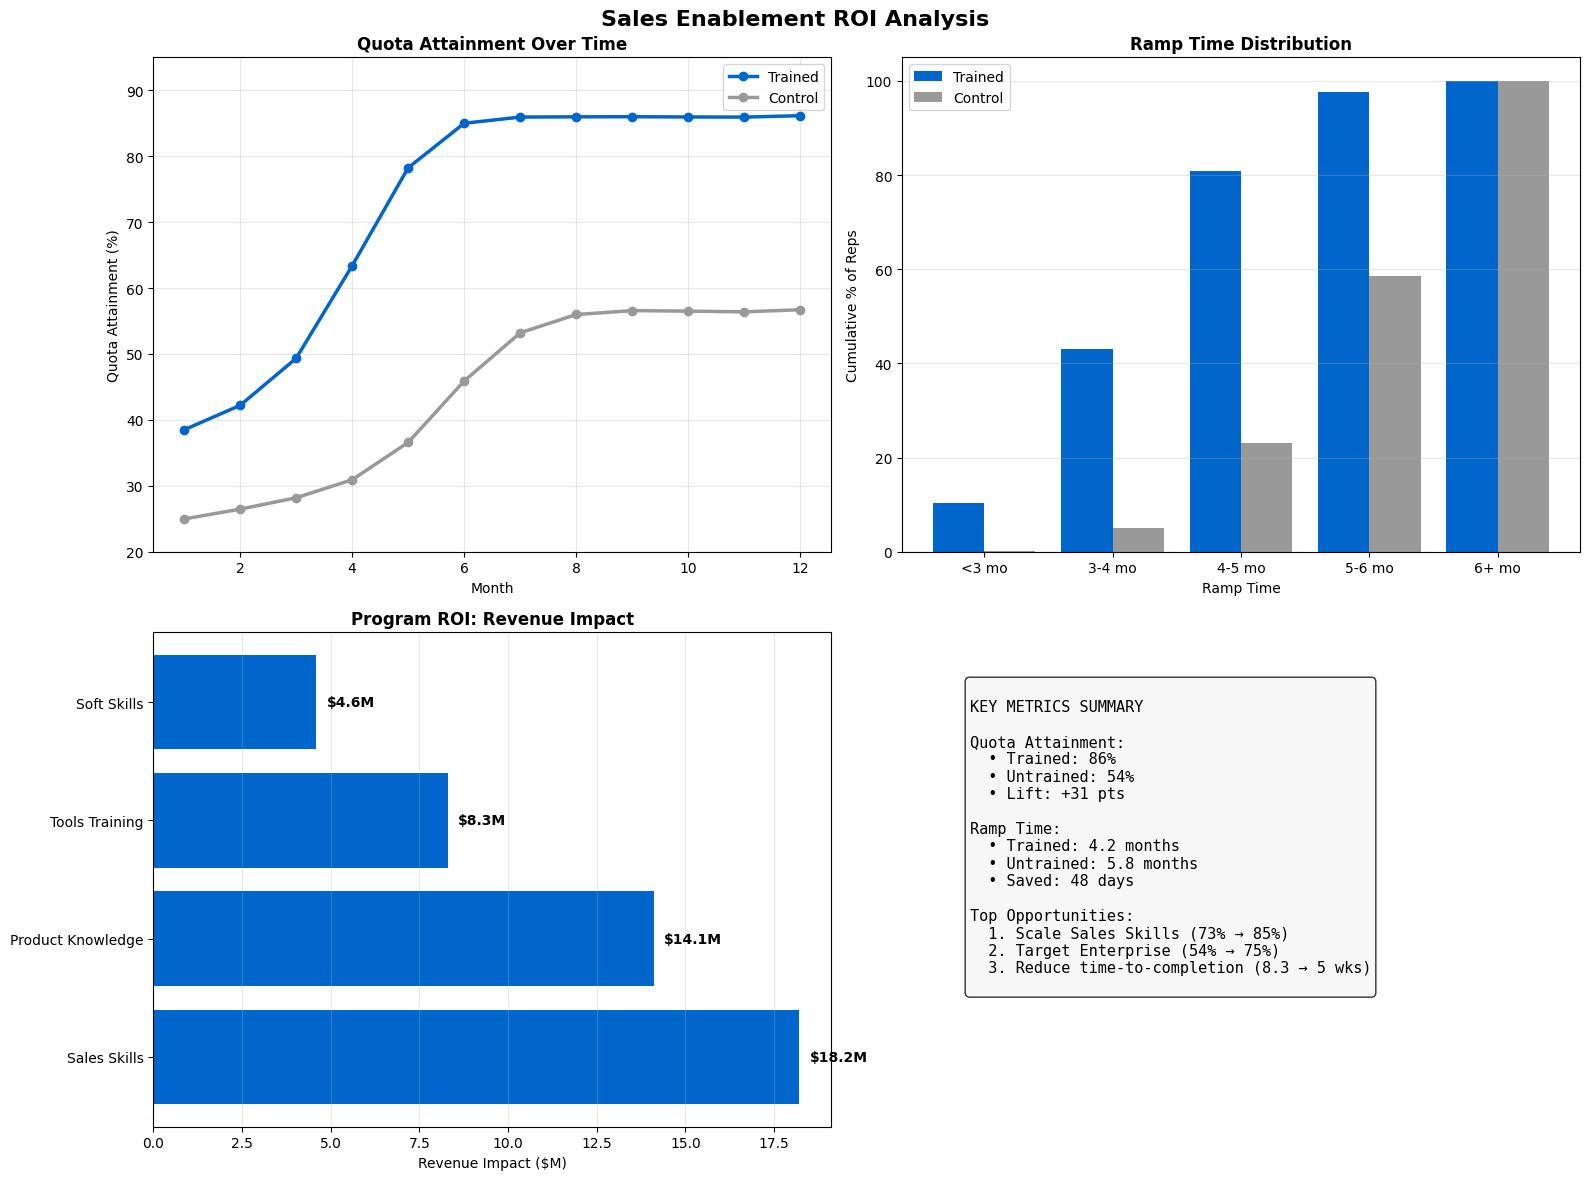

In [ ]:


import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Read your data
#reps_df = pd.read_csv('enablement_data/reps.csv')
#monthly_df = pd.read_csv('enablement_data/monthly_attainment.csv')
#program_df = pd.read_csv('enablement_data/programs.csv')

# Calculate metrics
trained_count = reps_df[reps_df['trained'] == 1].shape[0]
trained_ramp = reps_df[reps_df['trained'] == 1]['ramp_days'].mean()
untrained_ramp = reps_df[reps_df['trained'] == 0]['ramp_days'].mean()
trained_attainment = monthly_df[(monthly_df['trained'] == 1) & (monthly_df['month'] >= 6)]['quota_attainment'].mean() * 100
untrained_attainment = monthly_df[(monthly_df['trained'] == 0) & (monthly_df['month'] >= 6)]['quota_attainment'].mean() * 100

# Display Title
display(HTML('<h1 style="font-size: 28px;">Sales Enablement ROI Analysis</h1><p style="color: #666;">Measuring the impact of training programs</p>'))

# Display Metric Cards
display(HTML(f'''
<div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin: 2rem 0;">
    <div style="background: #f5f5f5; padding: 1.5rem; border-radius: 8px;">
        <p style="color: #999; font-size: 12px; text-transform: uppercase; margin-bottom: 8px;">Sales Reps</p>
        <p style="font-size: 28px; font-weight: 600;">9,247</p>
    </div>
    <div style="background: #f5f5f5; padding: 1.5rem; border-radius: 8px;">
        <p style="color: #999; font-size: 12px; text-transform: uppercase; margin-bottom: 8px;">Trained</p>
        <p style="font-size: 28px; font-weight: 600;">{trained_count:,}</p>
        <p style="font-size: 12px; color: #999;">66% participation</p>
    </div>
    <div style="background: #f5f5f5; padding: 1.5rem; border-radius: 8px;">
        <p style="color: #999; font-size: 12px; text-transform: uppercase; margin-bottom: 8px;">Quota Attainment</p>
        <p style="font-size: 28px; font-weight: 600;">{trained_attainment:.0f}%</p>
        <p style="font-size: 12px; color: #999;">vs {untrained_attainment:.0f}% untrained</p>
    </div>
    <div style="background: #f5f5f5; padding: 1.5rem; border-radius: 8px;">
        <p style="color: #999; font-size: 12px; text-transform: uppercase; margin-bottom: 8px;">Ramp Time</p>
        <p style="font-size: 28px; font-weight: 600;">{trained_ramp/30:.1f} mo</p>
        <p style="font-size: 12px; color: #999;">vs {untrained_ramp/30:.1f} mo</p>
    </div>
</div>
'''))

# Create Charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Enablement ROI Analysis', fontsize=16, fontweight='bold')

# Chart 1: Quota Attainment Over Time
ax1 = axes[0, 0]
monthly_by_status = monthly_df.groupby(['month', 'trained'])['quota_attainment'].mean().unstack()
months = monthly_by_status.index
ax1.plot(months, monthly_by_status[1] * 100, marker='o', linewidth=2.5, label='Trained', color='#0066cc')
ax1.plot(months, monthly_by_status[0] * 100, marker='o', linewidth=2.5, label='Control', color='#999999')
ax1.set_xlabel('Month')
ax1.set_ylabel('Quota Attainment (%)')
ax1.set_title('Quota Attainment Over Time', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(20, 95)

# Chart 2: Ramp Time Distribution
ax2 = axes[0, 1]
ramp_bins = ['<3 mo', '3-4 mo', '4-5 mo', '5-6 mo', '6+ mo']
trained_dist = []
untrained_dist = []
for cutoff in [90, 120, 150, 180, 250]:
    trained_pct = (reps_df[reps_df['trained'] == 1]['ramp_days'] <= cutoff).sum() / len(reps_df[reps_df['trained'] == 1]) * 100
    untrained_pct = (reps_df[reps_df['trained'] == 0]['ramp_days'] <= cutoff).sum() / len(reps_df[reps_df['trained'] == 0]) * 100
    trained_dist.append(trained_pct)
    untrained_dist.append(untrained_pct)

x = np.arange(len(ramp_bins))
ax2.bar(x - 0.2, trained_dist, 0.4, label='Trained', color='#0066cc')
ax2.bar(x + 0.2, untrained_dist, 0.4, label='Control', color='#999999')
ax2.set_xlabel('Ramp Time')
ax2.set_ylabel('Cumulative % of Reps')
ax2.set_title('Ramp Time Distribution', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(ramp_bins)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Chart 3: Program ROI
ax3 = axes[1, 0]
programs = program_df['program'].tolist()
roi_values = program_df['revenue_impact_millions'].tolist()
ax3.barh(programs, roi_values, color='#0066cc')
ax3.set_xlabel('Revenue Impact ($M)')
ax3.set_title('Program ROI: Revenue Impact', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(roi_values):
    ax3.text(v + 0.3, i, f'${v:.1f}M', va='center', fontweight='bold')

# Chart 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('off')
summary = f"""
KEY METRICS SUMMARY

Quota Attainment:
  • Trained: {trained_attainment:.0f}%
  • Untrained: {untrained_attainment:.0f}%
  • Lift: +{trained_attainment - untrained_attainment:.0f} pts

Ramp Time:
  • Trained: {trained_ramp/30:.1f} months
  • Untrained: {untrained_ramp/30:.1f} months
  • Saved: {(untrained_ramp - trained_ramp):.0f} days

Top Opportunities:
  1. Scale Sales Skills (73% → 85%)
  2. Target Enterprise (54% → 75%)
  3. Reduce time-to-completion (8.3 → 5 wks)
"""
ax4.text(0.1, 0.9, summary, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))

plt.tight_layout()
plt.show()
